In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Datos de ejemplo
datos = {
    "Estudiante": ["Ana", "Luis", "Sofía", "Carlos", "Marta"],
    "Lectura": [4.2, 3.8, 4.5, 3.9, 4.1],
    "Escritura": [3.7, 4.0, 4.2, 3.8, 3.9],
    "Escucha": [4.5, 4.2, 4.8, 4.0, 4.3],
    "Conversación": [3.9, 3.5, 4.3, 3.7, 4.0]
}

df = pd.DataFrame(datos)
df["Promedio"] = df[["Lectura", "Escritura", "Escucha", "Conversación"]].mean(axis=1)

display(df)


,Estudiante,Lectura,Escritura,Escucha,Conversación,Promedio
0,Ana,4.2,3.7,4.5,3.9,4.075
1,Luis,3.8,4.0,4.2,3.5,3.875
2,Sofía,4.5,4.2,4.8,4.3,4.450
3,Carlos,3.9,3.8,4.0,3.7,3.850
4,Marta,4.1,3.9,4.3,4.0,4.075


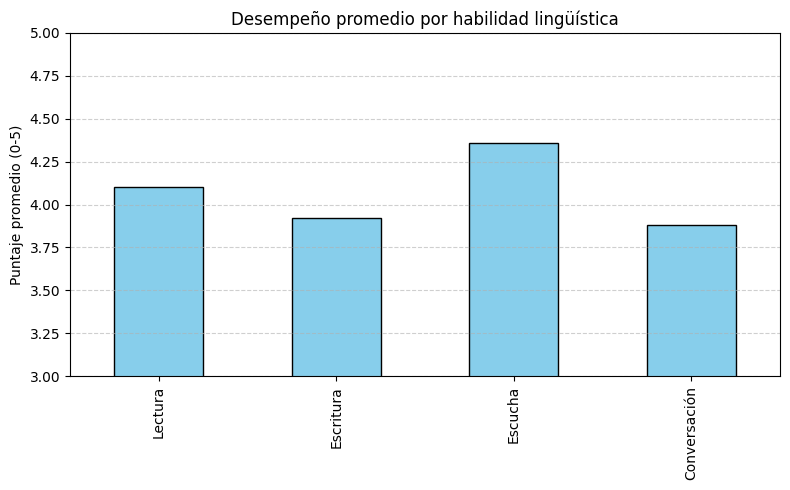

In [2]:
promedios_habilidad = df[["Lectura", "Escritura", "Escucha", "Conversación"]].mean()

plt.figure(figsize=(8,5))
promedios_habilidad.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Desempeño promedio por habilidad lingüística")
plt.ylabel("Puntaje promedio (0-5)")
plt.ylim(3,5)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [3]:
if promedios_habilidad["Conversación"] < 4.0:
    print("💬 Recomendación: fortalecer la expresión oral.")
elif promedios_habilidad["Escritura"] < 4.0:
    print("✍️ Recomendación: integrar más ejercicios de redacción.")
else:
    print("🌟 Buen equilibrio general entre comprensión y producción.")


💬 Recomendación: fortalecer la expresión oral.


In [4]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Variables predictoras (habilidades)
X = df[["Lectura", "Escritura", "Escucha", "Conversación"]]

# Variable objetivo (promedio general)
y = df["Promedio"]

# Crear modelo de regresión lineal
modelo = LinearRegression()
modelo.fit(X, y)

# Predicción de un nuevo estudiante
nuevo_estudiante = pd.DataFrame({
    "Lectura": [4.0],
    "Escritura": [3.8],
    "Escucha": [4.2],
    "Conversación": [3.9]
})

prediccion = modelo.predict(nuevo_estudiante)
print(f"Predicción del promedio futuro del nuevo estudiante: {round(prediccion[0],2)}")


Predicción del promedio futuro del nuevo estudiante: 3.97


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import ipywidgets as widgets
from IPython.display import display, clear_output

# Datos de ejemplo (grupo actual)
datos = {
    "Estudiante": ["Ana", "Luis", "Sofía", "Carlos", "Marta"],
    "Lectura": [4.2, 3.8, 4.5, 3.9, 4.1],
    "Escritura": [3.7, 4.0, 4.2, 3.8, 3.9],
    "Escucha": [4.5, 4.2, 4.8, 4.0, 4.3],
    "Conversación": [3.9, 3.5, 4.3, 3.7, 4.0]
}

df = pd.DataFrame(datos)
df["Promedio"] = df[["Lectura", "Escritura", "Escucha", "Conversación"]].mean(axis=1)

# Modelo de regresión
X = df[["Lectura", "Escritura", "Escucha", "Conversación"]]
y = df["Promedio"]
modelo = LinearRegression()
modelo.fit(X, y)

# --- Widgets de entrada ---
lectura_w = widgets.FloatSlider(value=4.0, min=0, max=5, step=0.1, description='Lectura:')
escritura_w = widgets.FloatSlider(value=4.0, min=0, max=5, step=0.1, description='Escritura:')
escucha_w = widgets.FloatSlider(value=4.0, min=0, max=5, step=0.1, description='Escucha:')
conversacion_w = widgets.FloatSlider(value=4.0, min=0, max=5, step=0.1, description='Conversación:')

boton = widgets.Button(description="Predecir promedio")
output = widgets.Output()

# --- Función de predicción ---
def predecir_promedio(b):
    clear_output(wait=True)
    display(lectura_w, escritura_w, escucha_w, conversacion_w, boton, output)
    
    nuevo_estudiante = pd.DataFrame({
        "Lectura": [lectura_w.value],
        "Escritura": [escritura_w.value],
        "Escucha": [escucha_w.value],
        "Conversación": [conversacion_w.value]
    })
    
    prediccion = modelo.predict(nuevo_estudiante)[0]
    
    with output:
        print(f"\nPredicción del promedio futuro: {round(prediccion,2)}")
        
        # Recomendación
        if lectura_w.value < 4.0:
            print("📚 Recomendación: reforzar lectura.")
        if escritura_w.value < 4.0:
            print("✍️ Recomendación: reforzar escritura.")
        if escucha_w.value < 4.0:
            print("👂 Recomendación: reforzar escucha.")
        if conversacion_w.value < 4.0:
            print("💬 Recomendación: reforzar conversación.")
        if all([lectura_w.value >= 4.0, escritura_w.value >= 4.0,
                escucha_w.value >= 4.0, conversacion_w.value >= 4.0]):
            print("🌟 Buen desempeño general.")

boton.on_click(predecir_promedio)

display(lectura_w, escritura_w, escucha_w, conversacion_w, boton, output)


FloatSlider(value=4.0, description='Lectura:', max=5.0)

FloatSlider(value=4.0, description='Escritura:', max=5.0)

FloatSlider(value=4.0, description='Escucha:', max=5.0)

FloatSlider(value=4.0, description='Conversación:', max=5.0)

Button(description='Predecir promedio', style=ButtonStyle())

Output()

In [2]:
# Guardar datos en archivo CSV
df.to_csv("notas_estudiantes.csv", index=False)
print("Archivo 'notas_estudiantes.csv' creado.")


Archivo 'notas_estudiantes.csv' creado.


In [3]:
# Cargar datos desde CSV
df_cargado = pd.read_csv("notas_estudiantes.csv")
display(df_cargado)


,Estudiante,Lectura,Escritura,Escucha,Conversación,Promedio
0,Ana,4.2,3.7,4.5,3.9,4.075
1,Luis,3.8,4.0,4.2,3.5,3.875
2,Sofía,4.5,4.2,4.8,4.3,4.450
3,Carlos,3.9,3.8,4.0,3.7,3.850
4,Marta,4.1,3.9,4.3,4.0,4.075


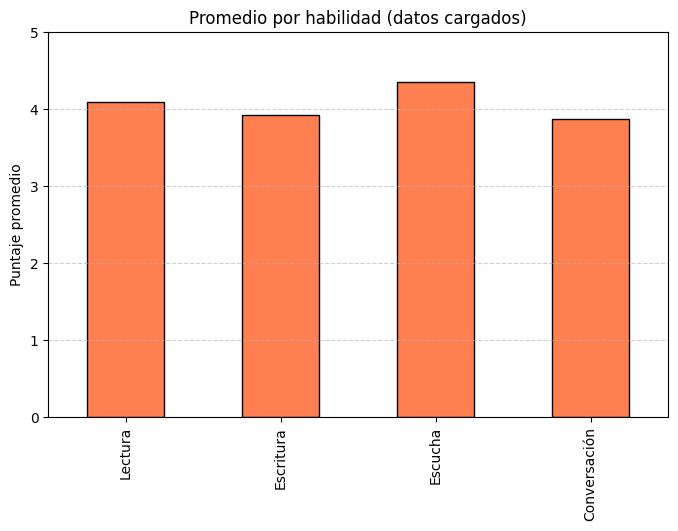

In [4]:
# Promedio por habilidad
promedios_habilidad = df_cargado[["Lectura", "Escritura", "Escucha", "Conversación"]].mean()

plt.figure(figsize=(8,5))
promedios_habilidad.plot(kind='bar', color='coral', edgecolor='black')
plt.title("Promedio por habilidad (datos cargados)")
plt.ylabel("Puntaje promedio")
plt.ylim(0,5)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


In [5]:
X = df_cargado[["Lectura", "Escritura", "Escucha", "Conversación"]]
y = df_cargado["Promedio"]


In [1]:
!pip install matplotlib scikit-learn ipywidgets



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Output()

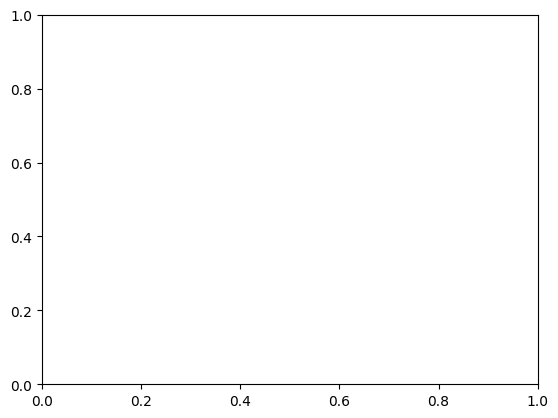

In [2]:
# -----------------------------
# Mini dashboard educativo con IA
# -----------------------------
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

# Datos simulados: participación (%), tareas entregadas, promedio final
participacion = np.array([40, 55, 60, 70, 80, 85, 90, 95, 100])
tareas = np.array([3, 4, 5, 6, 7, 7, 8, 9, 10])
promedio = np.array([2.8, 3.2, 3.5, 3.8, 4.0, 4.1, 4.3, 4.5, 4.8])

# Entrenamos un modelo lineal
X = np.column_stack((participacion, tareas))
modelo = LinearRegression()
modelo.fit(X, promedio)

# Widgets interactivos
slider_participacion = widgets.IntSlider(value=80, min=0, max=100, step=5, description='Participación:')
slider_tareas = widgets.IntSlider(value=7, min=0, max=10, step=1, description='Tareas:')

# Función para actualizar dashboard
def actualizar_dashboard(participacion, tareas):
    clear_output(wait=True)

    # Predicción
    pred = modelo.predict([[participacion, tareas]])[0]

    # Mostrar valores
    print(f"📊 Participación: {participacion}%")
    print(f"📝 Tareas entregadas: {tareas}")
    print(f"🎯 Promedio estimado: {round(pred, 2)}")

    # Gráfico
    fig, ax = plt.subplots()
    ax.scatter(promedio, participacion, color="skyblue", label="Estudiantes reales")
    ax.scatter(pred, participacion, color="red", s=100, label="Tu predicción")
    ax.set_xlabel("Promedio final")
    ax.set_ylabel("Participación (%)")
    ax.legend()
    plt.show()

# Mostrar dashboard
ui = widgets.VBox([slider_participacion, slider_tareas])
out = widgets.interactive_output(actualizar_dashboard, {
    'participacion': slider_participacion,
    'tareas': slider_tareas
})
display(ui, out)



In [4]:
def actualizar_dashboard(participacion, tareas):
    # Predicción
    pred = modelo.predict([[participacion, tareas]])[0]

    # Mostrar valores
    print(f"📊 Participación: {participacion}%")
    print(f"📝 Tareas entregadas: {tareas}")
    print(f"🎯 Promedio estimado: {round(pred, 2)}")

    # Gráfico
    fig, ax = plt.subplots()
    ax.scatter(promedio, participacion, color="skyblue", label="Estudiantes reales")
    ax.scatter(pred, participacion, color="red", s=100, label="Tu predicción")
    ax.set_xlabel("Promedio final")
    ax.set_ylabel("Participación (%)")
    ax.legend()
    plt.show()


Output()

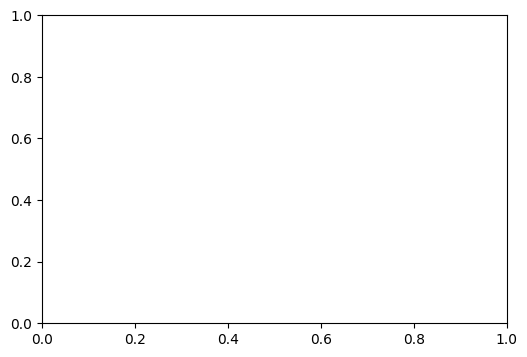

In [5]:
# -----------------------------
# Mini dashboard educativo con IA (versión estable)
# -----------------------------
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
import ipywidgets as widgets
from IPython.display import display

# --- Datos simulados ---
participacion = np.array([40, 55, 60, 70, 80, 85, 90, 95, 100])
tareas = np.array([3, 4, 5, 6, 7, 7, 8, 9, 10])
promedio = np.array([2.8, 3.2, 3.5, 3.8, 4.0, 4.1, 4.3, 4.5, 4.8])

# --- Entrenamiento del modelo ---
X = np.column_stack((participacion, tareas))
modelo = LinearRegression()
modelo.fit(X, promedio)

# --- Widgets interactivos ---
slider_participacion = widgets.IntSlider(
    value=80, min=0, max=100, step=5, description='Participación:', continuous_update=False
)
slider_tareas = widgets.IntSlider(
    value=7, min=0, max=10, step=1, description='Tareas:', continuous_update=False
)

# --- Función de actualización ---
def actualizar_dashboard(participacion, tareas):
    pred = modelo.predict([[participacion, tareas]])[0]

    # Mostrar información
    print("📊 Mini-dashboard de desempeño académico")
    print("--------------------------------------")
    print(f"Participación: {participacion}%")
    print(f"Tareas entregadas: {tareas}")
    print(f"🎯 Promedio estimado: {round(pred, 2)} / 5.0\n")

    # Crear gráfico
    fig, ax = plt.subplots(figsize=(6,4))
    ax.scatter(promedio, participacion, color="skyblue", label="Estudiantes reales")
    ax.scatter(pred, participacion, color="red", s=100, label="Tu predicción")
    ax.set_xlabel("Promedio final (estimado)")
    ax.set_ylabel("Participación (%)")
    ax.legend()
    plt.show()

# --- Mostrar interfaz ---
ui = widgets.VBox([slider_participacion, slider_tareas])
out = widgets.interactive_output(actualizar_dashboard, {
    'participacion': slider_participacion,
    'tareas': slider_tareas
})

display(ui, out)


In [6]:
# -----------------------------
# Mini dashboard educativo con IA (versión corregida y estable)
# -----------------------------
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
import ipywidgets as widgets
from IPython.display import display

# --- Datos simulados ---
participacion_data = np.array([40, 55, 60, 70, 80, 85, 90, 95, 100])
tareas_data = np.array([3, 4, 5, 6, 7, 7, 8, 9, 10])
promedio_data = np.array([2.8, 3.2, 3.5, 3.8, 4.0, 4.1, 4.3, 4.5, 4.8])

# --- Entrenamiento del modelo ---
X = np.column_stack((participacion_data, tareas_data))
modelo = LinearRegression()
modelo.fit(X, promedio_data)

# --- Widgets interactivos ---
slider_participacion = widgets.IntSlider(
    value=80, min=0, max=100, step=5, description='Participación:', continuous_update=False
)
slider_tareas = widgets.IntSlider(
    value=7, min=0, max=10, step=1, description='Tareas:', continuous_update=False
)

# --- Función de actualización ---
def actualizar_dashboard(valor_participacion, valor_tareas):
    pred = modelo.predict([[valor_participacion, valor_tareas]])[0]

    # Mostrar información
    print("📊 Mini-dashboard de desempeño académico")
    print("--------------------------------------")
    print(f"Participación: {valor_participacion}%")
    print(f"Tareas entregadas: {valor_tareas}")
    print(f"🎯 Promedio estimado: {round(pred, 2)} / 5.0\n")

    # Crear gráfico
    fig, ax = plt.subplots(figsize=(6,4))
    ax.scatter(promedio_data, participacion_data, color="skyblue", label="Estudiantes reales")
    ax.scatter(pred, valor_participacion, color="red", s=100, label="Tu predicción")
    ax.set_xlabel("Promedio final (estimado)")
    ax.set_ylabel("Participación (%)")
    ax.legend()
    plt.show()

# --- Mostrar interfaz ---
ui = widgets.VBox([slider_participacion, slider_tareas])
out = widgets.interactive_output(actualizar_dashboard, {
    'valor_participacion': slider_participacion,
    'valor_tareas': slider_tareas
})

display(ui, out)


Output()

In [7]:
# -----------------------------
# Mini dashboard educativo con IA (con barra de progreso)
# -----------------------------
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

# Datos simulados: participación (%), tareas entregadas, promedio final
participacion = np.array([40, 55, 60, 70, 80, 85, 90, 95, 100])
tareas = np.array([3, 4, 5, 6, 7, 7, 8, 9, 10])
promedio = np.array([2.8, 3.2, 3.5, 3.8, 4.0, 4.1, 4.3, 4.5, 4.8])

# Entrenamos un modelo lineal simple con dos variables
X = np.column_stack((participacion, tareas))
modelo = LinearRegression()
modelo.fit(X, promedio)

# Widgets interactivos
slider_participacion = widgets.IntSlider(value=80, min=0, max=100, step=5, description='Participación:')
slider_tareas = widgets.IntSlider(value=7, min=0, max=10, step=1, description='Tareas:')

# Barra de progreso (inicialmente vacía)
barra_promedio = widgets.FloatProgress(
    value=0,
    min=0,
    max=5,
    step=0.1,
    description='Promedio:',
    bar_style='',  # puede ser: 'success', 'info', 'warning', 'danger'
    orientation='horizontal'
)

# Etiqueta para mostrar el valor exacto del promedio
etiqueta_promedio = widgets.HTML(value="<b>Promedio estimado: --</b>")

# Función para actualizar dashboard
def actualizar_dashboard(participacion_val, tareas_val):
    clear_output(wait=True)

    # Predicción del modelo
    pred = modelo.predict([[participacion_val, tareas_val]])[0]

    # Actualizar barra de progreso y texto
    barra_promedio.value = pred
    if pred < 3:
        barra_promedio.bar_style = 'danger'
    elif pred < 4:
        barra_promedio.bar_style = 'warning'
    else:
        barra_promedio.bar_style = 'success'
    etiqueta_promedio.value = f"<b>🎯 Promedio estimado: {round(pred, 2)}</b>"

    # Mostrar valores
    print(f"📊 Participación: {participacion_val}%")
    print(f"📝 Tareas entregadas: {tareas_val}")

    # Crear gráfico
    fig, ax = plt.subplots(figsize=(6,4))
    ax.scatter(participacion, promedio, color="skyblue", label="Estudiantes reales")
    ax.scatter(participacion_val, pred, color="red", s=100, label="Tu predicción")
    ax.set_xlabel("Participación (%)")
    ax.set_ylabel("Promedio final")
    ax.legend()
    plt.show()

    # Mostrar barra y etiqueta
    display(barra_promedio, etiqueta_promedio)

# Mostrar dashboard
ui = widgets.VBox([slider_participacion, slider_tareas])
out = widgets.interactive_output(actualizar_dashboard, {
    'participacion_val': slider_participacion,
    'tareas_val': slider_tareas
})
display(ui, out)


Output()